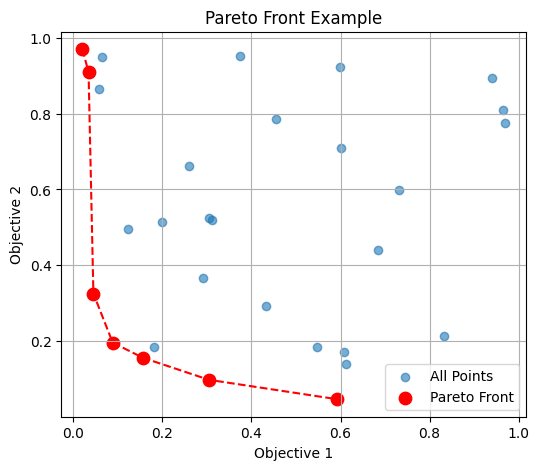

Pareto front indices: [ 2  5 14 18 21 28 29]
Pareto front points:
 [[0.15601864 0.15599452]
 [0.02058449 0.96990985]
 [0.59241457 0.04645041]
 [0.30461377 0.09767211]
 [0.03438852 0.9093204 ]
 [0.0884925  0.19598286]
 [0.04522729 0.32533033]]


In [5]:
# Pareto Front Calculation and Visualization in Python
import numpy as np
import matplotlib.pyplot as plt

def pareto_front(points):
    """
    Compute Pareto front indices from a set of points.
    
    Parameters:
        points (ndarray): Shape (n_points, n_objectives)
    
    Returns:
        front_indices (list): Indices of Pareto-optimal points
    """
    if not isinstance(points, np.ndarray):
        raise TypeError("Input must be a NumPy array.")
    if points.ndim != 2:
        raise ValueError("Input must be a 2D array of shape (n_points, n_objectives).")
    if points.shape[0] == 0:
        return []

    num_points = points.shape[0]
    is_dominated = np.zeros(num_points, dtype=bool)

    for i in range(num_points):
        for j in range(num_points):
            if i != j:
                # Check if point j dominates point i
                if np.all(points[j] <= points[i]) and np.any(points[j] < points[i]):
                    is_dominated[i] = True
                    break

    return np.where(~is_dominated)[0]

# Example: 2D Pareto front
np.random.seed(42)
data = np.random.rand(30, 2)  # 30 points, 2 objectives

# Get Pareto front indices
front_idx = pareto_front(data)
pareto_points = data[front_idx]

# Plot results
plt.figure(figsize=(6, 5))
plt.scatter(data[:, 0], data[:, 1], label="All Points", alpha=0.6)
plt.scatter(pareto_points[:, 0], pareto_points[:, 1], color="red", label="Pareto Front", s=80)
plt.plot(pareto_points[np.argsort(pareto_points[:, 0])][:, 0],
         pareto_points[np.argsort(pareto_points[:, 0])][:, 1],
         color="red", linestyle="--")
plt.xlabel("Objective 1")
plt.ylabel("Objective 2")
plt.title("Pareto Front Example")
plt.legend()
plt.grid(True)
plt.show()

print("Pareto front indices:", front_idx)
print("Pareto front points:\n", pareto_points)


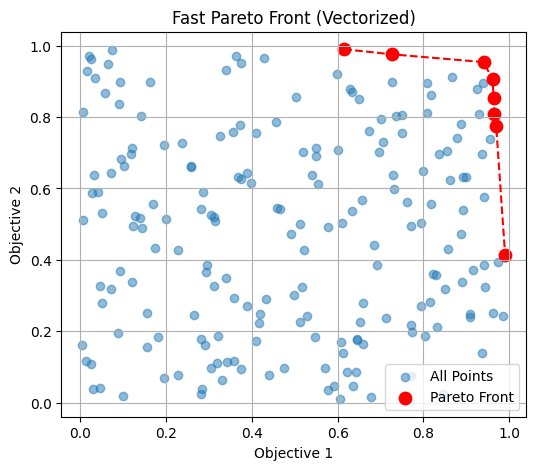

Pareto front size (10k points): 9


In [6]:
import numpy as np
import matplotlib.pyplot as plt

def pareto_front_fast(points):
    """
    Fast Pareto front computation using NumPy broadcasting.
    
    Parameters:
        points (ndarray): Shape (n_points, n_objectives)
    
    Returns:
        front_indices (ndarray): Indices of Pareto-optimal points
    """
    if not isinstance(points, np.ndarray):
        raise TypeError("Input must be a NumPy array.")
    if points.ndim != 2:
        raise ValueError("Input must be a 2D array of shape (n_points, n_objectives).")
    if points.shape[0] == 0:
        return np.array([], dtype=int)

    # Compare all points against each other
    less_equal = np.all(points[:, None] <= points[None, :], axis=2)
    strictly_less = np.any(points[:, None] < points[None, :], axis=2)

    # A point is dominated if another point is <= in all objectives and < in at least one
    dominated = np.any(less_equal & strictly_less, axis=1)

    return np.where(~dominated)[0]

# Example: Large dataset
np.random.seed(42)
data = np.random.rand(10000, 2)  # 10k points, 2 objectives

# Compute Pareto front
front_idx = pareto_front_fast(data)
pareto_points = data[front_idx]

# Plot only for small datasets (avoid plotting 10k points for speed)
sample_data = data[:200]
sample_front_idx = pareto_front_fast(sample_data)
sample_pareto_points = sample_data[sample_front_idx]

plt.figure(figsize=(6, 5))
plt.scatter(sample_data[:, 0], sample_data[:, 1], alpha=0.5, label="All Points")
plt.scatter(sample_pareto_points[:, 0], sample_pareto_points[:, 1], color="red", s=80, label="Pareto Front")
plt.plot(sample_pareto_points[np.argsort(sample_pareto_points[:, 0])][:, 0],
         sample_pareto_points[np.argsort(sample_pareto_points[:, 0])][:, 1],
         color="red", linestyle="--")
plt.xlabel("Objective 1")
plt.ylabel("Objective 2")
plt.title("Fast Pareto Front (Vectorized)")
plt.legend()
plt.grid(True)
plt.show()

print(f"Pareto front size (10k points): {len(front_idx)}")


In [12]:
def f1(x):
    return x
def f2(x):
    return 1 - x**2 + 4*(x-1.5)**3

for x in np.arange(0, 2.1, 0.4):
    print(f"x: {x:.2f}, f1: {f1(x):.2f}, f2: {f2(x):.2f}")

x: 0.00, f1: 0.00, f2: -12.50
x: 0.40, f1: 0.40, f2: -4.48
x: 0.80, f1: 0.80, f2: -1.01
x: 1.20, f1: 1.20, f2: -0.55
x: 1.60, f1: 1.60, f2: -1.56
x: 2.00, f1: 2.00, f2: -2.50


s -> A -> C -> t
s -> A -> C -> B -> t
s -> A -> C -> B -> D -> t
s -> A -> C -> D -> t
s -> A -> B -> t
s -> A -> B -> D -> t
s -> A -> E -> C -> t
s -> A -> E -> C -> B -> t
s -> A -> E -> C -> B -> D -> t
s -> A -> E -> C -> D -> t
s -> B -> t
s -> B -> D -> t
s -> E -> C -> t
s -> E -> C -> B -> t
s -> E -> C -> B -> D -> t
s -> E -> C -> D -> t

Total paths: 16
Path: s -> A -> C -> t, Time: 24, Distance: 7
Path: s -> A -> C -> B -> t, Time: 27, Distance: 12
Path: s -> A -> C -> B -> D -> t, Time: 27, Distance: 16
Path: s -> A -> C -> D -> t, Time: 26, Distance: 11
Path: s -> A -> B -> t, Time: 20, Distance: 11
Path: s -> A -> B -> D -> t, Time: 20, Distance: 15
Path: s -> A -> E -> C -> t, Time: 24, Distance: 9
Path: s -> A -> E -> C -> B -> t, Time: 27, Distance: 14
Path: s -> A -> E -> C -> B -> D -> t, Time: 27, Distance: 18
Path: s -> A -> E -> C -> D -> t, Time: 26, Distance: 13
Path: s -> B -> t, Time: 12, Distance: 12
Path: s -> B -> D -> t, Time: 12, Distance: 16
Path: s -

Text(0, 0.5, 'Distance')

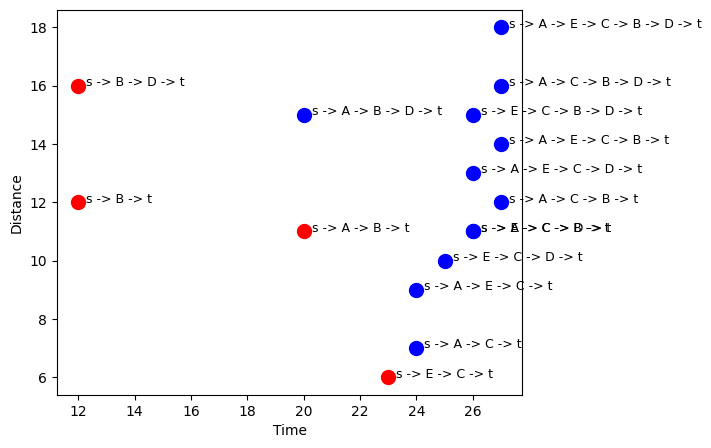

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def enumerate_paths(network, start, end):
    all_paths = []
    
    def dfs(current, path, visited):
        if current == end:
            all_paths.append(tuple(path))
            return
        
        for (u, v) in network:
            if u == current and v not in visited:
                dfs(v, path + [v], visited | {v})
    
    dfs(start, [start], {start})
    return all_paths



# Network: each link is (from, to): (time, distance)
network = {
    ('s', 'A'): (7, 2),
    ('s', 'B'): (5, 8),
    ('s', 'E'): (10, 1),   # very slow, very short
    ('A', 'C'): (9, 3),
    ('A', 'B'): (6, 5),
    ('A', 'E'): (4, 2),
    ('B', 't'): (7, 4),
    ('B', 'D'): (3, 6),    # fast, long
    ('C', 't'): (8, 2),
    ('C', 'B'): (4, 3),
    ('C', 'D'): (6, 4),
    ('D', 't'): (4, 2),    # fast, short
    ('E', 'C'): (5, 3),
}

# Enumerate paths from s to t
paths = enumerate_paths(network, 's', 't')
for p in paths:
    print(' -> '.join(p))
print(f"\nTotal paths: {len(paths)}")


path_metrics = {path: {'time': 0, 'distance': 0} for path in paths}


# TODO: for each path, compute total time and total distance
# Hint: zip consecutive nodes to get links, look them up in network
for path in paths:
    for link in zip(path, path[1:]):
        time, distance = network[link]
        path_metrics[path]['time'] += time
        path_metrics[path]['distance'] += distance
    print(f"Path: {' -> '.join(path)}, Time: {path_metrics[path]['time']}, Distance: {path_metrics[path]['distance']}")


# TODO: identify which paths are Pareto optimal
# Hint: a path is dominated if another path is better in both time AND distance
pareto_optimal_paths = []
for path in paths:
    dominated = False
    for other_path in paths:
        if path != other_path:
            if (path_metrics[other_path]['time'] < path_metrics[path]['time'] and
                path_metrics[other_path]['distance'] < path_metrics[path]['distance']):
                dominated = True
                break
    if not dominated:
        pareto_optimal_paths.append(path)
print(pareto_optimal_paths)


# TODO: plot all paths in objective space (time vs distance)
# mark Pareto optimal points differently from dominated ones
plt.figure(figsize=(6,5))
for path in paths:
    time = path_metrics[path]['time']
    distance = path_metrics[path]['distance']
    if path in pareto_optimal_paths:
        plt.scatter(time, distance, color='red', s=100, label='Pareto Optimal' if 'Pareto Optimal' not in plt.gca().get_legend_handles_labels()[1] else "")
        plt.text(time, distance, '  ' + ' -> '.join(path), fontsize=9)
    else:
        plt.scatter(time, distance, color='blue', s=100, label='Dominated' if 'Dominated' not in plt.gca().get_legend_handles_labels()[1] else "")
        plt.text(time, distance, '  ' + ' -> '.join(path), fontsize=9)

plt.xlabel('Time')
plt.ylabel('Distance')

C:\Users\kpolage\AppData\Local\Temp\ipykernel_14892\3529440267.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


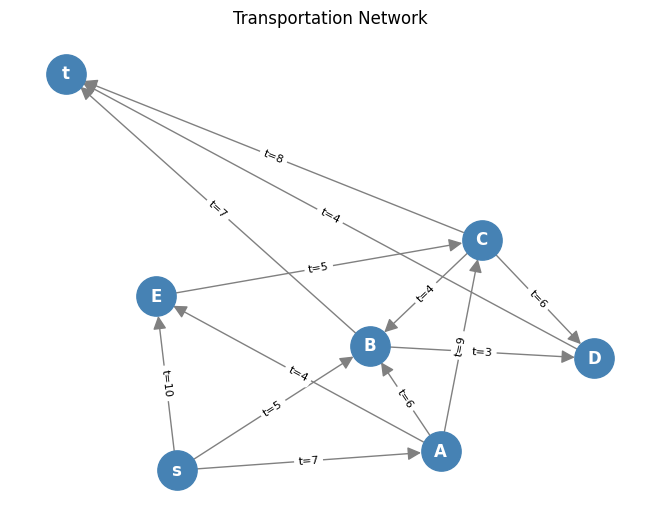

C:\Users\kpolage\AppData\Local\Temp\ipykernel_14892\3529440267.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


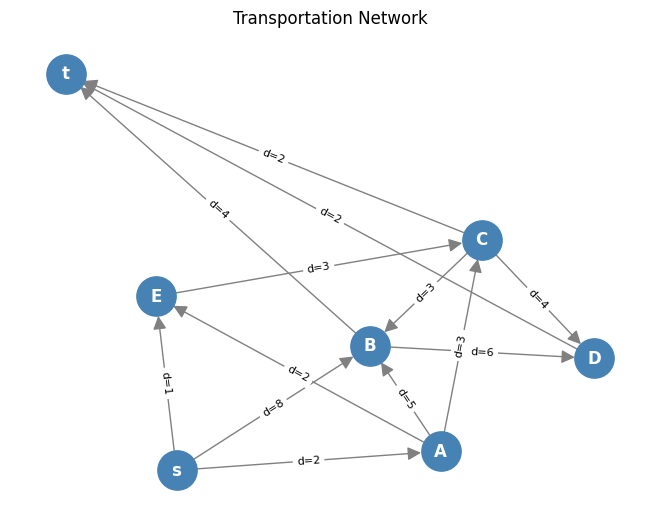

In [9]:
import networkx as nx
import matplotlib.pyplot as plt

# Build directed graph
G = nx.DiGraph()
for (u, v), (time, distance) in network.items():
    G.add_edge(u, v, time=time, distance=distance)

# Layout
pos = nx.spring_layout(G, seed=42)

# Draw nodes and edges
nx.draw(G, pos, with_labels=True, node_color='steelblue', 
        node_size=800, font_color='white', font_weight='bold',
        arrows=True, arrowsize=20, edge_color='gray')

# Edge labels showing travel time
time_edge_labels = {(u, v): f"t={d['time']}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=time_edge_labels, font_size=8)

plt.title("Transportation Network")
plt.tight_layout()
plt.show()


# Build directed graph
G = nx.DiGraph()
for (u, v), (time, distance) in network.items():
    G.add_edge(u, v, time=time, distance=distance)

# Layout
pos = nx.spring_layout(G, seed=42)

# Draw nodes and edges
nx.draw(G, pos, with_labels=True, node_color='steelblue', 
        node_size=800, font_color='white', font_weight='bold',
        arrows=True, arrowsize=20, edge_color='gray')

# Edge labels showing travel time
dist_edge_labels = {(u, v): f"d={d['distance']}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=dist_edge_labels, font_size=8)

plt.title("Transportation Network")
plt.tight_layout()
plt.show()

In [1]:
import heapq

def dijkstra(network, start, end, weight):
    # priority queue: (cost, node)
    queue = [(0, start)]
    visited = {}
    predecessors = {}

    while queue:
        cost, node = heapq.heappop(queue)

        if node in visited:
            continue
        visited[node] = cost

        if node == end:
            break

        for (u, v), costs in network.items():
            if u == node:
                edge_cost = costs[0] if weight == 'time' else costs[1]
                new_cost = cost + edge_cost

                # TODO: if v not visited, push (new_cost, v) to queue
                if v not in visited:
                    heapq.heappush(queue, (new_cost, v))
                    # TODO: update predecessors[v] = node
                    if v not in predecessors or new_cost < predecessors[v][1]:
                        predecessors[v] = (node, new_cost)

    # TODO: reconstruct path by walking back through predecessors from end to start
    path = []
    current = end
    while current != start:
        path.append(current)
        current = predecessors[current][0]
    path.append(start)
    path.reverse()

    return path, visited[end]


# Find shortest time path
time_path, time_cost = dijkstra(network, 's', 't', weight='time')
print(f"Shortest time path: {' -> '.join(time_path)}, Time: {time_cost}")

# Find shortest distance path
distance_path, distance_cost = dijkstra(network, 's', 't', weight='distance')
print(f"Shortest distance path: {' -> '.join(distance_path)}, Distance: {distance_cost}")

NameError: name 'network' is not defined

# Time Dependency

In [83]:
network_td = {
    ('s', 'A'): {'morning': 13, 'offpeak': 8,  'evening': 11, 'night': 6},
    ('s', 'B'): {'morning': 8,  'offpeak': 5,  'evening': 7,  'night': 4},
    ('s', 'C'): {'morning': 19, 'offpeak': 12, 'evening': 16, 'night': 9},
    ('A', 'D'): {'morning': 11, 'offpeak': 7,  'evening': 10, 'night': 5},
    ('A', 'E'): {'morning': 13, 'offpeak': 8,  'evening': 11, 'night': 6},
    ('B', 'D'): {'morning': 8,  'offpeak': 5,  'evening': 7,  'night': 4},
    ('B', 'F'): {'morning': 16, 'offpeak': 10, 'evening': 14, 'night': 8},
    ('C', 'F'): {'morning': 10, 'offpeak': 6,  'evening': 9,  'night': 4},
    ('C', 'G'): {'morning': 14, 'offpeak': 9,  'evening': 12, 'night': 7},
    ('D', 'H'): {'morning': 11, 'offpeak': 7,  'evening': 10, 'night': 5},
    ('D', 'I'): {'morning': 18, 'offpeak': 11, 'evening': 15, 'night': 8},
    ('E', 'H'): {'morning': 8,  'offpeak': 5,  'evening': 7,  'night': 4},
    ('E', 'I'): {'morning': 13, 'offpeak': 8,  'evening': 11, 'night': 6},
    ('F', 'G'): {'morning': 6,  'offpeak': 4,  'evening': 5,  'night': 3},
    ('F', 'J'): {'morning': 11, 'offpeak': 7,  'evening': 10, 'night': 5},
    ('G', 'J'): {'morning': 16, 'offpeak': 10, 'evening': 14, 'night': 8},
    ('G', 'K'): {'morning': 8,  'offpeak': 5,  'evening': 7,  'night': 4},
    ('H', 'L'): {'morning': 13, 'offpeak': 8,  'evening': 11, 'night': 6},
    ('H', 'M'): {'morning': 8,  'offpeak': 5,  'evening': 7,  'night': 4},
    ('I', 'L'): {'morning': 10, 'offpeak': 6,  'evening': 9,  'night': 4},
    ('I', 'M'): {'morning': 14, 'offpeak': 9,  'evening': 12, 'night': 7},
    ('J', 'K'): {'morning': 11, 'offpeak': 7,  'evening': 10, 'night': 5},
    ('J', 'N'): {'morning': 18, 'offpeak': 11, 'evening': 15, 'night': 8},
    ('K', 'N'): {'morning': 8,  'offpeak': 5,  'evening': 7,  'night': 4},
    ('K', 't'): {'morning': 13, 'offpeak': 8,  'evening': 11, 'night': 6},
    ('L', 'N'): {'morning': 11, 'offpeak': 7,  'evening': 10, 'night': 5},
    ('L', 't'): {'morning': 16, 'offpeak': 10, 'evening': 14, 'night': 8},
    ('M', 'N'): {'morning': 8,  'offpeak': 5,  'evening': 7,  'night': 4},
    ('M', 't'): {'morning': 13, 'offpeak': 8,  'evening': 11, 'night': 6},
    ('N', 't'): {'morning': 6,  'offpeak': 4,  'evening': 5,  'night': 3},
}

def get_travel_time(link, t):
    if 6*60 <= t < 10*60:
        period = 'morning'
    elif 10*60 <= t < 16*60:
        period = 'offpeak'
    elif 16*60 <= t < 20*60:
        period = 'evening'
    else:
        period = 'night'
    return network_td[link][period]

In [84]:
def dijkstra_td(network_td, start, end, departure_time):
    # priority queue: (cost, node)
    queue = [(0, start, departure_time)]
    visited = {}
    predecessors = {}

    while queue:
        cost, node, t = heapq.heappop(queue)

        if node in visited:
            continue
        visited[node] = cost

        if node == end:
            break

        for (u, v) in network_td:
            if u == node:
                travel_time = get_travel_time((u, v), t)
                #edge_cost = costs[0] if weight == 'time' else costs[1]
                #new_cost = cost + edge_cost
                new_cost = cost + travel_time
                arrival_time = t + travel_time

                # TODO: if v not visited, push (new_cost, v) to queue
                if v not in visited:
                    heapq.heappush(queue, (new_cost, v, arrival_time))
                    # TODO: update predecessors[v] = node
                    if v not in predecessors or new_cost < predecessors[v][1]:
                        predecessors[v] = (node, new_cost)

    # TODO: reconstruct path by walking back through predecessors from end to start
    path = []
    current = end
    while current != start:
        path.append(current)
        current = predecessors[current][0]
    path.append(start)
    path.reverse()

    return path, visited[end]

for t in [8*60, 12*60, 17*60]:
    path, cost = dijkstra_td(network_td, 's', 't', departure_time=t)
    print(f"Departure t={t}: {' -> '.join(path)}, cost={cost}")

Departure t=480: s -> B -> D -> H -> M -> t, cost=48
Departure t=720: s -> B -> D -> H -> M -> t, cost=30
Departure t=1020: s -> B -> D -> H -> M -> t, cost=42


C:\Users\kpolage\AppData\Local\Temp\ipykernel_26044\1404705039.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


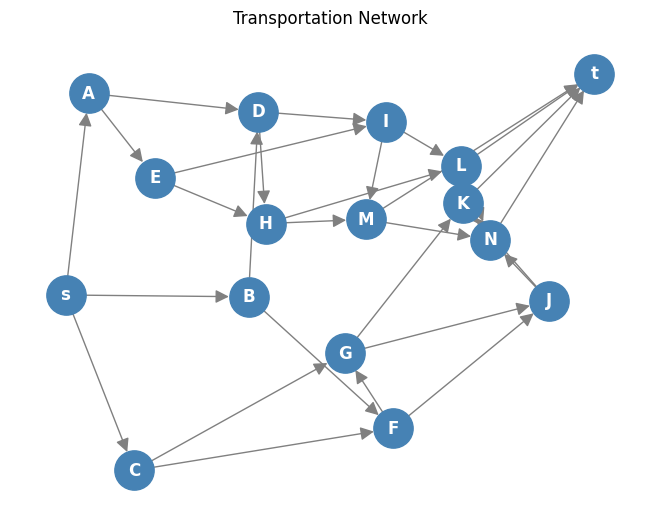

In [85]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()
for (u, v) in network_td:
    G.add_edge(u, v)

pos = nx.spring_layout(G, seed=42)

# Draw nodes and edges
nx.draw(G, pos, with_labels=True, node_color='steelblue', 
        node_size=800, font_color='white', font_weight='bold',
        arrows=True, arrowsize=20, edge_color='gray')

# Edge labels showing travel time
#dist_edge_labels = {(u, v): f"d={d['distance']}" for u, v, d in G.edges(data=True)}
#nx.draw_networkx_edge_labels(G, pos, edge_labels=dist_edge_labels, font_size=8)

plt.title("Transportation Network")
plt.tight_layout()
plt.show()

# Backward Induction

In [86]:
## Forward induction

policy = {}

for node in G.nodes():
    for t in range(1440):
        if node == 't':
            continue
        path, cost = dijkstra_td(network_td, node, 't', departure_time=t)
        print(f"From {node} at t={t}: {' -> '.join(path)}, cost={cost}")
        policy[(node, t)] = path[1] # optimal next decision from (n,t)

From s at t=0: s -> B -> D -> H -> M -> t, cost=23
From s at t=1: s -> B -> D -> H -> M -> t, cost=23
From s at t=2: s -> B -> D -> H -> M -> t, cost=23
From s at t=3: s -> B -> D -> H -> M -> t, cost=23
From s at t=4: s -> B -> D -> H -> M -> t, cost=23
From s at t=5: s -> B -> D -> H -> M -> t, cost=23
From s at t=6: s -> B -> D -> H -> M -> t, cost=23
From s at t=7: s -> B -> D -> H -> M -> t, cost=23
From s at t=8: s -> B -> D -> H -> M -> t, cost=23
From s at t=9: s -> B -> D -> H -> M -> t, cost=23
From s at t=10: s -> B -> D -> H -> M -> t, cost=23
From s at t=11: s -> B -> D -> H -> M -> t, cost=23
From s at t=12: s -> B -> D -> H -> M -> t, cost=23
From s at t=13: s -> B -> D -> H -> M -> t, cost=23
From s at t=14: s -> B -> D -> H -> M -> t, cost=23
From s at t=15: s -> B -> D -> H -> M -> t, cost=23
From s at t=16: s -> B -> D -> H -> M -> t, cost=23
From s at t=17: s -> B -> D -> H -> M -> t, cost=23
From s at t=18: s -> B -> D -> H -> M -> t, cost=23
From s at t=19: s -> B

In [87]:
V = {(n,t): float('inf') for n in G.nodes() for t in range(1440)}
policy2 = {}

for t in range(1440):
    V[('t', t)] = 0 # boundary conditions

# Backwards induction
for _ in range(2):
    for t in range(1440, -1, -1):
        for node in reversed(list(nx.topological_sort(G))):
            if node == 't': # skip terminal node
                continue
            best_cost = float('inf')
            best_next = None

            for (u, v) in G.edges():
                if u == node:
                    travel_time = get_travel_time((u,v), t)
                    arrival_time = (t + travel_time) % 1440
                    cost = travel_time + V[(v, arrival_time)]
                    if cost < best_cost:
                        best_cost = cost
                        best_next = v

            V[(node, t)] = best_cost
            if best_next is not None:
                policy2[(node, t)] = best_next

In [88]:
# Check against Dijkstra's policy to make sure working for deterministic cases

mismatches = []
for (node, t), next_node in policy.items():
    if (node, t) in policy2:
        if policy2[(node, t)] != next_node:
            mismatches.append((node, t, next_node, policy2[(node, t)]))

if mismatches:
    for node, t, p1, p2 in mismatches:
        print(f"({node}, t={t}): Dijkstra={p1}, DP={p2}")
else:
    print("Policies match!")

(s, t=356): Dijkstra=C, DP=B
(s, t=357): Dijkstra=C, DP=B
(s, t=358): Dijkstra=C, DP=B
(s, t=359): Dijkstra=C, DP=B
(A, t=562): Dijkstra=E, DP=D
(A, t=570): Dijkstra=E, DP=D
(A, t=578): Dijkstra=E, DP=D
(A, t=1173): Dijkstra=E, DP=D
(A, t=1174): Dijkstra=E, DP=D
(A, t=1180): Dijkstra=E, DP=D
(A, t=1181): Dijkstra=E, DP=D
(B, t=578): Dijkstra=F, DP=D
(B, t=579): Dijkstra=F, DP=D
(B, t=580): Dijkstra=F, DP=D
(B, t=955): Dijkstra=F, DP=D
(B, t=956): Dijkstra=F, DP=D
(B, t=957): Dijkstra=F, DP=D
(B, t=958): Dijkstra=F, DP=D
(B, t=959): Dijkstra=F, DP=D
(B, t=1186): Dijkstra=F, DP=D
(B, t=1187): Dijkstra=F, DP=D
(B, t=1188): Dijkstra=F, DP=D
(B, t=1189): Dijkstra=F, DP=D
(B, t=1190): Dijkstra=F, DP=D
(B, t=1191): Dijkstra=F, DP=D
(B, t=1192): Dijkstra=F, DP=D
(C, t=0): Dijkstra=G, DP=F
(C, t=1): Dijkstra=G, DP=F
(C, t=2): Dijkstra=G, DP=F
(C, t=3): Dijkstra=G, DP=F
(C, t=4): Dijkstra=G, DP=F
(C, t=5): Dijkstra=G, DP=F
(C, t=6): Dijkstra=G, DP=F
(C, t=7): Dijkstra=G, DP=F
(C, t=8): Dijkstra=

In [89]:
def extract_path(policy, start, t, max_steps=20):
    path = [start]
    node = start
    for _ in range(max_steps):
        if node == 't' or (node, t) not in policy:
            break
        next_node = policy[(node, t)]
        travel_time = get_travel_time((node, next_node), t)
        t = (t + travel_time) % 1440
        path.append(next_node)
        node = next_node
    return path

The methods may still differ because they are solving slightly different problems. Dijkstra's is moving forward, while DP is moving backwards. Since Dijkstra's is moving forward, it is greedy and short-sided. Thus the DP cases below are always better when the two methods differ.

In [90]:
for node, t, p1, p2 in mismatches:
    path_dijkstra = extract_path(policy, node, t)
    path_dp = extract_path(policy2, node, t)
    _, cost_d = dijkstra_td(network_td, node, 't', t)
    if cost_d != V[(node, t)]:
        print(f"\n({node}, t={t}):")
        print(f"  Dijkstra: {' -> '.join(path_dijkstra)}, cost={cost_d}")
        print(f"  DP:       {' -> '.join(path_dp)}, cost={V[(node, t)]}")


(A, t=570):
  Dijkstra: A -> E -> H -> M -> N -> t, cost=41
  DP:       A -> D -> H -> M -> t, cost=38

(A, t=578):
  Dijkstra: A -> E -> H -> M -> t, cost=37
  DP:       A -> D -> H -> M -> t, cost=35

(A, t=1173):
  Dijkstra: A -> E -> H -> M -> N -> t, cost=35
  DP:       A -> D -> H -> M -> t, cost=33

(A, t=1174):
  Dijkstra: A -> E -> H -> M -> N -> t, cost=35
  DP:       A -> D -> H -> M -> t, cost=33

(A, t=1180):
  Dijkstra: A -> E -> H -> M -> t, cost=31
  DP:       A -> D -> H -> M -> t, cost=30

(A, t=1181):
  Dijkstra: A -> E -> H -> M -> t, cost=31
  DP:       A -> D -> H -> M -> t, cost=30

(C, t=576):
  Dijkstra: C -> G -> K -> N -> t, cost=34
  DP:       C -> F -> G -> K -> t, cost=32

(C, t=577):
  Dijkstra: C -> G -> K -> N -> t, cost=34
  DP:       C -> F -> G -> K -> t, cost=32

(C, t=584):
  Dijkstra: C -> G -> K -> t, cost=30
  DP:       C -> F -> G -> K -> t, cost=29

(C, t=585):
  Dijkstra: C -> G -> K -> t, cost=30
  DP:       C -> F -> G -> K -> t, cost=29



# Stochastic Travel Times

In [143]:
# (base_mean, base_std) representing free-flow travel time
# higher mean = longer link, higher std = more variable
# travel times now in minutes (5-15 min per link)
network_params = {
    ('s', 'A'): (8, 2),
    ('s', 'B'): (5, 1),
    ('s', 'C'): (12, 3),
    ('A', 'D'): (7, 2),
    ('A', 'E'): (8, 2),
    ('B', 'D'): (5, 1),
    ('B', 'F'): (10, 6),
    ('C', 'F'): (6, 1),
    ('C', 'G'): (9, 2),
    ('D', 'H'): (7, 2),
    ('D', 'I'): (11, 3),
    ('E', 'H'): (5, 1),
    ('E', 'I'): (8, 2),
    ('F', 'G'): (4, 3),
    ('F', 'J'): (7, 2),
    ('G', 'J'): (10, 3),
    ('G', 'K'): (5, 5),
    ('H', 'L'): (8, 2),
    ('H', 'M'): (5, 1),
    ('I', 'L'): (6, 1),
    ('I', 'M'): (9, 2),
    ('J', 'K'): (7, 2),
    ('J', 'N'): (11, 3),
    ('K', 'N'): (5, 1),
    ('K', 't'): (8, 5),
    ('L', 'N'): (7, 2),
    ('L', 't'): (10, 3),
    ('M', 'N'): (5, 1),
    ('M', 't'): (8, 2),
    ('N', 't'): (4, 1),
}

## Example to show risk avoidance

In [144]:
'''network_params = {
    # Path 1 — fast but very risky (mean=9, std=5)
    ('s', 'B'): (9, 5),
    ('B', 'D'): (9, 5),
    ('D', 'H'): (9, 5),
    ('H', 'M'): (9, 5),
    ('M', 't'): (9, 5),

    # Path 2 — slightly slower but very reliable (mean=10, std=0.5)
    ('s', 'A'): (10, 0.5),
    ('A', 'E'): (10, 0.5),
    ('E', 'I'): (10, 0.5),
    ('I', 'L'): (10, 0.5),
    ('L', 'N'): (10, 0.5),
    ('N', 't'): (10, 0.5),

    # Path 3 — middle ground (mean=11, std=2)
    ('s', 'C'): (11, 2),
    ('C', 'F'): (11, 2),
    ('F', 'J'): (11, 2),
    ('J', 'K'): (11, 2),
    ('K', 't'): (11, 2),

    # all other links — very expensive
    ('A', 'D'): (50, 2),
    ('B', 'F'): (50, 2),
    ('C', 'G'): (50, 2),
    ('D', 'I'): (50, 2),
    ('E', 'H'): (50, 2),
    ('F', 'G'): (50, 2),
    ('G', 'J'): (50, 2),
    ('G', 'K'): (50, 2),
    ('H', 'L'): (50, 2),
    ('I', 'M'): (50, 2),
    ('J', 'N'): (50, 2),
    ('K', 'N'): (50, 2),
    ('L', 't'): (50, 2),
    ('M', 'N'): (50, 2),
}
'''

"network_params = {\n    # Path 1 — fast but very risky (mean=9, std=5)\n    ('s', 'B'): (9, 5),\n    ('B', 'D'): (9, 5),\n    ('D', 'H'): (9, 5),\n    ('H', 'M'): (9, 5),\n    ('M', 't'): (9, 5),\n\n    # Path 2 — slightly slower but very reliable (mean=10, std=0.5)\n    ('s', 'A'): (10, 0.5),\n    ('A', 'E'): (10, 0.5),\n    ('E', 'I'): (10, 0.5),\n    ('I', 'L'): (10, 0.5),\n    ('L', 'N'): (10, 0.5),\n    ('N', 't'): (10, 0.5),\n\n    # Path 3 — middle ground (mean=11, std=2)\n    ('s', 'C'): (11, 2),\n    ('C', 'F'): (11, 2),\n    ('F', 'J'): (11, 2),\n    ('J', 'K'): (11, 2),\n    ('K', 't'): (11, 2),\n\n    # all other links — very expensive\n    ('A', 'D'): (50, 2),\n    ('B', 'F'): (50, 2),\n    ('C', 'G'): (50, 2),\n    ('D', 'I'): (50, 2),\n    ('E', 'H'): (50, 2),\n    ('F', 'G'): (50, 2),\n    ('G', 'J'): (50, 2),\n    ('G', 'K'): (50, 2),\n    ('H', 'L'): (50, 2),\n    ('I', 'M'): (50, 2),\n    ('J', 'N'): (50, 2),\n    ('K', 'N'): (50, 2),\n    ('L', 't'): (50, 2),\n    

In [172]:
def get_mean(base_mean, t):
    # peaks at t=480 (8am) and t=1020 (5pm) in minutes
    congestion = 1 + 0.5 * (np.exp(-0.5*((t-480)/60)**2) + 0.7*np.exp(-0.5*((t-1020)/60)**2))
    return base_mean * congestion

def get_std(base_std, t):
    congestion = 1 + 0.3 * (np.exp(-0.5*((t-480)/60)**2) + 0.7*np.exp(-0.5*((t-1020)/60)**2))
    return base_std * congestion

def get_stochastic_travel_time(link, t):
    base_mean, base_std = network_params[link]
    mean = get_mean(base_mean, t)
    std = get_std(base_std, t)
    return max(1, round(np.random.normal(mean, std)))

def new_expected_cost(link, t, V, v, lam=0.5): # change lambda here
    # Monte Carlo estimate of expected cost by sampling travel times
    samples = [get_stochastic_travel_time(link, t) for _ in range(100)] # change below as well
    arrival_times = [(t + s) % 1440 for s in samples]
    total_costs = [s + V[(v, a)] for s, a in zip(samples, arrival_times)]
    mean = np.mean(total_costs)
    var = np.var(total_costs)
    return mean + lam * var

In [152]:
import numpy as np
V_s = {(n, t): float('inf') for n in G.nodes() for t in range(1440)}
policy_s = {}

for t in range(1440):
    V_s[('t', t)] = 0

for _ in range(2): # to go back and cover initial runs without connections to terminus
    for t in range(1439, -1, -1):
        for node in reversed(list(nx.topological_sort(G))):
            if node == 't':
                continue
            best_cost = float('inf')
            best_next = None

            for (u, v) in G.edges():
                if u == node:
                    cost = new_expected_cost((u, v), t, V_s, v)
                    if cost < best_cost:
                        best_cost = cost
                        best_next = v

            V_s[(node, t)] = best_cost
            if best_next is not None:
                policy_s[(node, t)] = best_next

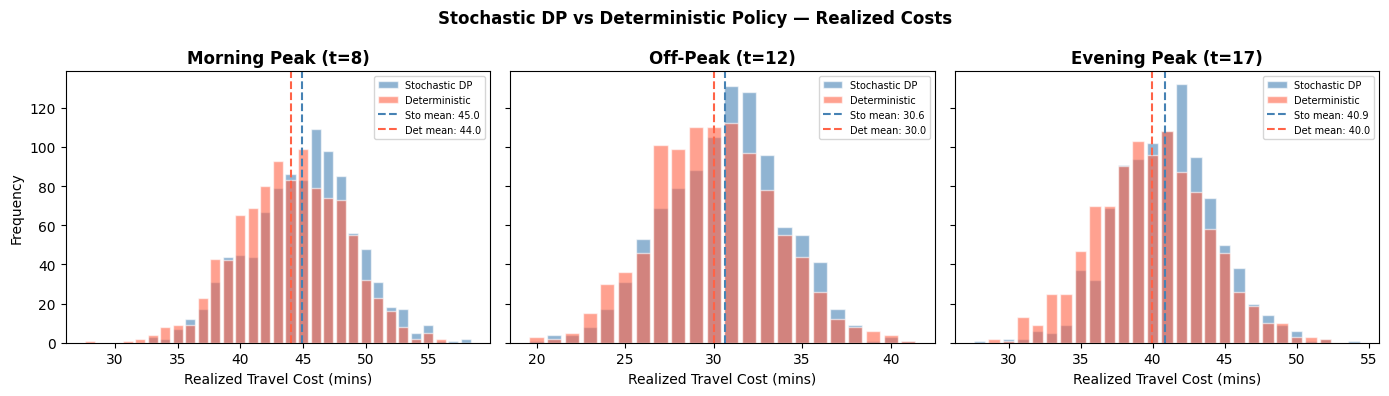

Departure                   Sto Mean   Det Mean    Sto Std    Det Std Sto Utility Det Utility
-----------------------------------------------------------------
Morning Peak (t=8)             44.96      44.02       4.21       4.22     46.01     45.07
Off-Peak (t=12)                30.62      30.04       3.34       3.45     31.45     30.90
Evening Peak (t=17)            40.89      39.97       3.51       3.87     41.77     40.93


In [153]:
def simulate_trip(policy, start, t):
    path = [start]
    node = start
    time = t
    total_cost = 0

    while node != 't':
        next_node = policy.get((node, time % 1440), None)
        path.append(next_node)
        travel_time = get_stochastic_travel_time((node, next_node), time % 1440)
        total_cost += travel_time
        time += travel_time
        node = next_node

    return path, total_cost


departure_times = [8*60, 12*60, 17*60]
n = 1000

#results = {}
#for t in departure_times:
#    costs = []
#    paths = []
#    for _ in range(n):
#        path, cost = simulate_trip(policy_s, 's', t)
#        costs.append(cost)
#        paths.append('->'.join(path))
#    results[t] = {'costs': costs, 'paths': paths}
results_sto = {}
results_det = {}

for t in departure_times:
    sto_costs, det_costs = [], []
    sto_paths, det_paths = [], []
    
    for _ in range(n):
        path_s, cost_s = simulate_trip(policy_s, 's', t)
        path_d, cost_d = simulate_trip(policy, 's', t)
        
        sto_costs.append(cost_s)
        det_costs.append(cost_d)
        sto_paths.append('->'.join(path_s))
        det_paths.append('->'.join(path_d))
    
    results_sto[t] = {'costs': sto_costs, 'paths': sto_paths}
    results_det[t] = {'costs': det_costs, 'paths': det_paths}


#fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
#
#colors = ['steelblue', 'seagreen', 'tomato']
#labels = ['Morning Peak (t=8)', 'Off-Peak (t=12)', 'Evening Peak (t=17)']
#
#for ax, (t, color, label) in zip(axes, zip(departure_times, colors, labels)):
#    costs = results[t]['costs']
#    bins = range(min(costs), max(costs) + 2) # integer bins
#    ax.hist(costs, bins=bins, align='left', rwidth=0.8, color=color, alpha=0.8, edgecolor='white')
#    ax.axvline(np.mean(costs), color='black', linestyle='--', linewidth=1.5, label=f'Mean: {np.mean(costs):.2f}')
#    ax.axvline(np.median(costs), color='gray', linestyle=':', linewidth=1.5, label=f'Median: {np.median(costs):.2f}')
#    ax.set_title(label, fontweight='bold')
#    ax.set_xlabel('Realized Travel Cost')
#    ax.legend(fontsize=8)
#
#axes[0].set_ylabel('Frequency')
#fig.suptitle('Distribution of Realized Travel Costs by Departure Time', fontweight='bold', y=1.02)
#plt.tight_layout()
#plt.show()
#
## summary stats
#print(f"{'Departure':<15} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
#print("-" * 47)
#for t, label in zip(departure_times, labels):
#    costs = results[t]['costs']
#    print(f"{label:<15} {np.mean(costs):>8.2f} {np.std(costs):>8.2f} {np.min(costs):>8} {np.max(costs):>8}")
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

labels = ['Morning Peak (t=8)', 'Off-Peak (t=12)', 'Evening Peak (t=17)']

for ax, (t, label) in zip(axes, zip(departure_times, labels)):
    sto_costs = results_sto[t]['costs']
    det_costs = results_det[t]['costs']
    
    all_costs = sto_costs + det_costs
    bins = range(min(all_costs), max(all_costs) + 2)
    
    ax.hist(sto_costs, bins=bins, align='left', rwidth=0.8, 
            alpha=0.6, color='steelblue', edgecolor='white', label='Stochastic DP')
    ax.hist(det_costs, bins=bins, align='left', rwidth=0.8, 
            alpha=0.6, color='tomato', edgecolor='white', label='Deterministic')
    
    ax.axvline(np.mean(sto_costs), color='steelblue', linestyle='--', linewidth=1.5, 
               label=f'Sto mean: {np.mean(sto_costs):.1f}')
    ax.axvline(np.mean(det_costs), color='tomato', linestyle='--', linewidth=1.5, 
               label=f'Det mean: {np.mean(det_costs):.1f}')
    
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Realized Travel Cost (mins)')
    ax.legend(fontsize=7)

axes[0].set_ylabel('Frequency')
fig.suptitle('Stochastic DP vs Deterministic Policy — Realized Costs', fontweight='bold')
plt.tight_layout()
plt.show()

# summary comparison
print(f"{'Departure':<25} {'Sto Mean':>10} {'Det Mean':>10} {'Sto Std':>10} {'Det Std':>10} {'Sto Utility':>10} {'Det Utility':>10}")
print("-" * 65)
for t, label in zip(departure_times, labels):
    print(f"{label:<25} {np.mean(results_sto[t]['costs']):>10.2f} "
          f"{np.mean(results_det[t]['costs']):>10.2f} "
          f"{np.std(results_sto[t]['costs']):>10.2f} "
          f"{np.std(results_det[t]['costs']):>10.2f}"
          f"{np.mean(results_sto[t]['costs']) + 0.25 * np.std(results_sto[t]['costs']):>10.2f}"
          f"{np.mean(results_det[t]['costs']) + 0.25 * np.std(results_det[t]['costs']):>10.2f}")

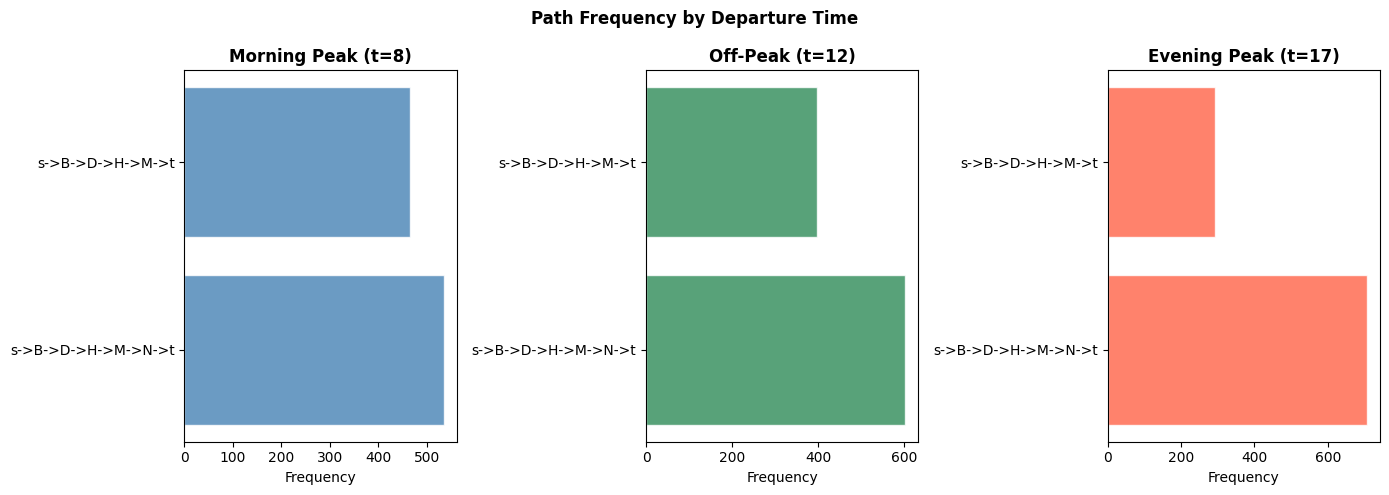

In [154]:
from collections import Counter

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, (t, color, label) in zip(axes, zip(departure_times, colors, labels)):
    path_counts = Counter(results_sto[t]['paths'])
    paths, counts = zip(*sorted(path_counts.items(), key=lambda x: -x[1]))
    ax.barh(paths, counts, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Frequency')

fig.suptitle('Path Frequency by Departure Time', fontweight='bold')
plt.tight_layout()
plt.show()

In [157]:
def on_time_rate(costs, departure_time, target_arrival):
    on_time = sum(1 for c in costs if c + departure_time <= target_arrival)
    return on_time / len(costs)

targets = {
    8*60:  8*60 + 50,   # depart 8am, target 9am
    12*60: 12*60 + 35,  # depart 12pm, target 12:45pm
    17*60: 17*60 + 45,  # depart 5pm, target 6pm
}

In [158]:
on_time_results = {}
for t, target in targets.items():
    on_time_results[t] = {
        'Stochastic DP': on_time_rate(results_sto[t]['costs'], t, target),
        'Deterministic': on_time_rate(results_det[t]['costs'], t, target)
    }
print(f"{'Departure':<25} {'Stochastic DP':>15} {'Deterministic':>15}")
print("-" * 55)
for t, label in zip(departure_times, labels):
    print(f"{label:<25} {on_time_results[t]['Stochastic DP']*100:>14.1f}% {on_time_results[t]['Deterministic']*100:>14.1f}%")

Departure                   Stochastic DP   Deterministic
-------------------------------------------------------
Morning Peak (t=8)                  91.6%           94.4%
Off-Peak (t=12)                     92.8%           94.3%
Evening Peak (t=17)                 90.9%           92.7%


# Departure Time Schedule Delay

In [190]:
# Schedule delay parameters
T_star = 9 * 60    # desired arrival time: 9am (540 minutes)
alpha = 0.5        # cost per minute early
beta = 1.0         # cost per minute late (late is worse) # don't make too big or will cause cost explosion

def schedule_delay(arrival_time):
    early = max(T_star - arrival_time, 0)
    late = max(arrival_time - T_star, 0)
    return alpha * early + beta * late

In [191]:
V_sd = {(n, t): float('inf') for n in G.nodes() for t in range(1440)}
policy_sd = {}

for t in range(1440):
    V_sd[('t', t)] = schedule_delay(t)

for _ in range(2): # to go back and cover initial runs without connections to terminus
    for t in range(1439, -1, -1):
        for node in reversed(list(nx.topological_sort(G))):
            if node == 't':
                continue
            best_cost = float('inf')
            best_next = None

            for (u, v) in G.edges():
                if u == node:
                    cost = new_expected_cost((u, v), t, V_sd, v)
                    if cost < best_cost:
                        best_cost = cost
                        best_next = v

            V_sd[(node, t)] = best_cost
            if best_next is not None:
                policy_sd[(node, t)] = best_next

In [192]:
best_departure = min(range(1440), key=lambda t: V_sd[('s', t)])
print(f"Optimal departure time from s: {best_departure//60}:{best_departure%60:02d} with expected schedule delay travel time (cost): {V_sd[('s', best_departure)]:.2f}")

Optimal departure time from s: 8:05 with expected schedule delay travel time (cost): 52.31


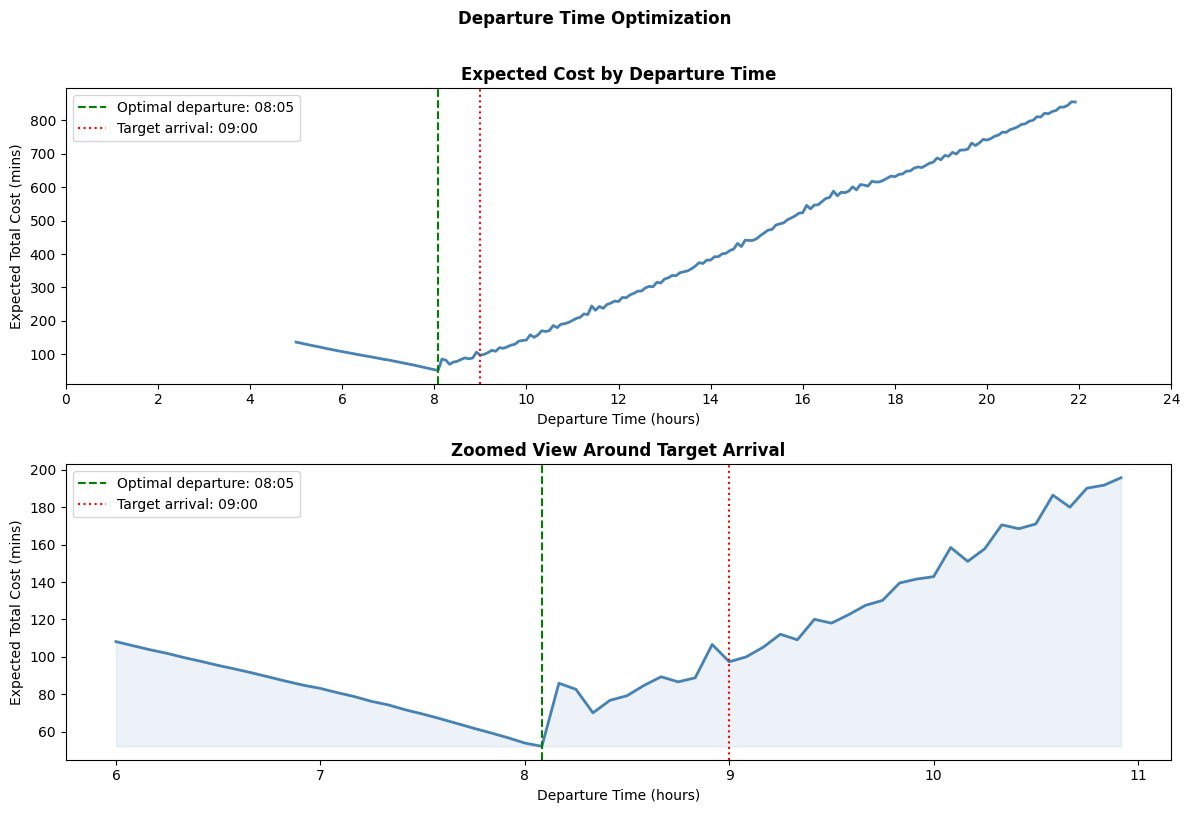

Optimal departure time: 08:05
Expected total cost at optimal departure: 52.31 mins
Expected arrival time: 8:57
Target arrival time: 09:00
Optimal path: s -> B -> D -> H -> M -> N -> t


In [193]:
departure_range = range(5*60, 22*60, 5)  # every 5 minutes, during non free flow hours

expected_costs = [V_sd[('s', t)] for t in departure_range]
best_t = min(departure_range, key=lambda t: V_sd[('s', t)])
best_cost = V_sd[('s', best_t)]

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# top plot: full cost curve
axes[0].plot([t/60 for t in departure_range], expected_costs, 
             color='steelblue', linewidth=2)
axes[0].axvline(best_t/60, color='green', linestyle='--', linewidth=1.5,
                label=f'Optimal departure: {best_t//60:02d}:{best_t%60:02d}')
axes[0].axvline(T_star/60, color='red', linestyle=':', linewidth=1.5,
                label=f'Target arrival: {T_star//60:02d}:{T_star%60:02d}')
axes[0].set_xlabel('Departure Time (hours)')
axes[0].set_ylabel('Expected Total Cost (mins)')
axes[0].set_title('Expected Cost by Departure Time', fontweight='bold')
axes[0].legend()
axes[0].set_xticks(range(0, 25, 2))

# bottom plot: zoom into the interesting window around T_star
window_start = max(0, T_star - 3*60)
window_end = min(1440, T_star + 2*60)
window_range = range(window_start, window_end, 5)
window_costs = [V_sd[('s', t)] for t in window_range]

axes[1].plot([t/60 for t in window_range], window_costs,
             color='steelblue', linewidth=2)
axes[1].axvline(best_t/60, color='green', linestyle='--', linewidth=1.5,
                label=f'Optimal departure: {best_t//60:02d}:{best_t%60:02d}')
axes[1].axvline(T_star/60, color='red', linestyle=':', linewidth=1.5,
                label=f'Target arrival: {T_star//60:02d}:{T_star%60:02d}')
axes[1].fill_between([t/60 for t in window_range], window_costs,
                      min(window_costs), alpha=0.1, color='steelblue')
axes[1].set_xlabel('Departure Time (hours)')
axes[1].set_ylabel('Expected Total Cost (mins)')
axes[1].set_title('Zoomed View Around Target Arrival', fontweight='bold')
axes[1].legend()

fig.suptitle('Departure Time Optimization', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# print summary
print(f"Optimal departure time: {best_t//60:02d}:{best_t%60:02d}")
print(f"Expected total cost at optimal departure: {best_cost:.2f} mins")
print(f"Expected arrival time: {(best_t + best_cost)//60:.0f}:{(best_t + best_cost)%60:.0f}")
print(f"Target arrival time: {T_star//60:02d}:{T_star%60:02d}")

# show optimal path
optimal_path = extract_path(policy_sd, 's', best_t)
print(f"Optimal path: {' -> '.join(optimal_path)}")